<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#The-idea" data-toc-modified-id="The-idea-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>The idea</a></span></li><li><span><a href="#Load-some-modules" data-toc-modified-id="Load-some-modules-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Load some modules</a></span></li><li><span><a href="#Define-parameters" data-toc-modified-id="Define-parameters-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Define parameters</a></span></li><li><span><a href="#Computations" data-toc-modified-id="Computations-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Computations</a></span></li><li><span><a href="#Plot" data-toc-modified-id="Plot-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Plot</a></span></li></ul></div>

# Julia: making Julia sets with Newton's Method

## The idea


The *complex $n^\mathrm{th}$ roots of unity* is the set of numbers $\{z_0, z_1,
\dots, z_{n-1}\}$ such that $(z_k)^n=1$. For example, the
4th roots of unity are $1$, $-1$, $i=\sqrt{-1}$ and $-i$. 
 
More generally, they can be expressed as
$$
z_k=e^{i \theta} \quad \text{ where } 
\theta =  \frac{2k\pi}{n}
\qquad \text{ for } k \in \{0, 1, 2 \dots, n-1\}.
$$
Suppose we wanted to estimate these numbers using 
Newton's method. We could try to
solve $f(z)=0$ with $f(z)=z^n-1$. The  iteration is:
$$
 z_{k+1}= z_k - \frac{(z_k)^n -1}{n (z_k)^{n-1}}.
$$

However, there are $n$ possible solutions to
$$
  z^n-1=0.
$$
Given a particular starting
point, which root with the method converge to? If we take a number of
points in a region of space, iterate on each of them, and then colour
the points to indicate the ones that converge to the same root, we get
the  famous **Julia Set**.

## Load some modules

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Define parameters
* `n` is the number of roots
* `N` defines the resolution. Larger values give nicer pictures, but are slower to run

In [2]:
n = 4    # nth roots of unity
N = 400  # resolution (N^2 points)
Max_Iterations = 1000
x0, x1 = -1.1, 1.1 # corners for domain
y0, y1 = -1.1, 1.1 # corners for domain

## Computations

In [3]:
k = np.arange(n) # do not include zero
Roots = np.cos(k*2*np.pi/n) + 1j*np.sin(k*2*np.pi/n)

x = np.linspace(x0,x1,N)
y = np.linspace(y0,y1,N)
X, Y = np.meshgrid(x, y) # Grid of complex numbers
Z = X+1j*Y

# Newton iteration
for _ in range(Max_Iterations):
    Z = Z - (Z**n-1)/(n*Z**(n-1))

# Classification of convergence
T = np.zeros(Z.shape, dtype=int)
for j in range(n):
    T[np.abs(Z-Roots[j]) <= 1e-3] = j+1

## Plot

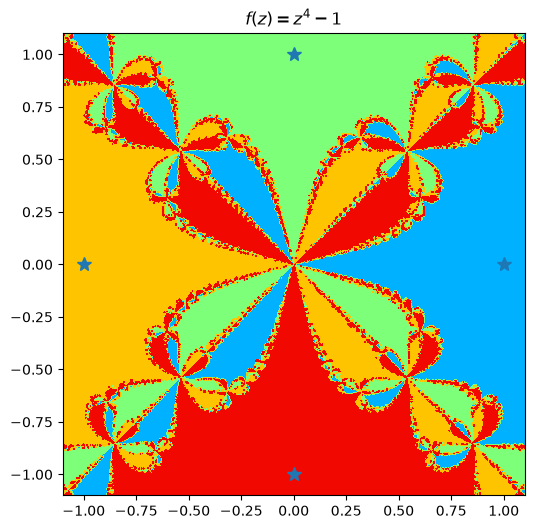

In [4]:
fig, ax = plt.subplots(figsize=(6,6))
c = ax.contourf(x, y, T, levels=n+1, cmap="jet")
ax.set_title(f"$f(z) = z^{n} - 1$")
ax.set_aspect("equal")

ax.plot(Roots.real, Roots.imag, '*', markersize=10,linewidth=4)
plt.savefig("Julia.png", dpi=300, bbox_inches="tight")
plt.show()